In [76]:
from typing import Optional, Tuple, List
from math import gcd, ceil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [77]:

def get_dense_batch_position(m: int, n: int, k:int, b:int, N1:int, core_id: int, round_id: int) -> Optional[Tuple[int, int, int]]:

    k = min(k, b*N1*m, b*n)
    R = max(ceil(b*n*N1/k), ceil(n/m), N1)
    
    if core_id < 1 or core_id > k or round_id < 1 or round_id > R*m:
        return None
    

    ID = (core_id - 1) * R + ceil(round_id/m)
    local_id = round_id%m or m
    

    if ID > N1*n*b:
        return None
    
    N = b*N1
    b_id = ID % N or N
    b_id = ceil(b_id/N1)
    y = ceil(ID/N)
    w = ID % N1 or N1

    
    g = gcd(N, R)
    t1 = R // g
    #实际不需要计算t2也可以 因为t2*R就是t1*b
    t2 = N // g
    
    t1_new = t1 * m
    y1 = y%t1_new or t1_new
    offset = ceil(y1/t1) 

    if t1_new < n:
        n1 = (n % t1_new) or t1_new
        if y <= n - n1:
            delta = ceil(y / t1_new)
            ID += delta
            if ID > (delta-1) * t2 * m * R + offset * t2 * R:
                ID -= t2 * R
                
            ###20251224
            b_id = ID % N or N
            b_id = ceil(b_id/N1)
            ###
            
            w = ID % N1 or N1
            y = ceil(ID/N)

  
    x = local_id + offset - 1
    if x>m:
        x -= m

    return (w+(b_id-1)*N1, x, y)

In [78]:

def visualize_dense_schedule(
    m: List[int], n: List[int], k: int, b: int, N1:int
):
    """
    可视化 dense 调度坐标结果（使用 get_dense_batch_position）

    Parameters:
        k: 核心数
        m, n: 各 batch 的行数和列数
        b: batch 数目
    """
    k = min(k, b*N1*m, b*n)
    print('k:', k)
    R = max(ceil(b*n*N1/k), ceil(n/m), N1) * m
    print('R:', R)
    
    cmap1 = plt.get_cmap('tab20', 20)
    cmap2 = plt.get_cmap('tab20b', 20)
    cmap3 = plt.get_cmap('tab20c', 20)

    # 合并颜色列表（共 60 种）
    all_colors = list(cmap1.colors) + list(cmap2.colors) + list(cmap3.colors)

    # === 简单随机打乱，避免相邻相似 ===
    np.random.seed(42)  # 固定随机种子以复现结果（可删）
    np.random.shuffle(all_colors)

    # 选取前 32 种颜色
    selected_colors = all_colors[:32]
    # === 构建 cmap ===
    cmap = ListedColormap(selected_colors, name='shuffled32')

    for w in range(1, b*N1 + 1):
        rounds_mat = np.zeros((m, n), dtype=int)
        core_mat = np.zeros((m, n), dtype=int)

        for core_id in range(1, k + 1):
            for round_id in range(1, R + 1):
                pos = get_dense_batch_position(m, n, k, b, N1, core_id, round_id)
                if pos is None:
                    continue
                batch_id, x, y = pos
                
#                 if round_id == 6:
#                     print('core:',core_id,'pos:',(batch_id,x,y))
                
                if batch_id == w and 1 <= x <= m and 1 <= y <= n:
                    rounds_mat[x - 1, y - 1] = round_id
                    core_mat[x - 1, y - 1] = core_id

        # 绘图
        fig, ax = plt.subplots(figsize=(3, 3 * m / n))
#         cmap = plt.get_cmap('tab20', k)
        im = ax.imshow(core_mat, origin='upper',
                       cmap=cmap, vmin=1, vmax=k, aspect='auto')

        ax.set_xticks(np.arange(n + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(m + 1) - 0.5, minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
        ax.tick_params(which='minor', length=0)

        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(m))
        ax.set_xticklabels(np.arange(1, n + 1))
        ax.set_yticklabels(np.arange(1, m + 1))

        for i in range(m):
            for j in range(n):
                r_id = rounds_mat[i, j]
                if r_id > 0:
                    ax.text(j, i, str(r_id),
                            ha='center', va='center',
                            fontsize=10, color='white')

        ax.set_title(f"Dense Schedule | k={k}, batch={w}, size=({m}×{n})")
        ax.set_xlabel("Column (y)")
        ax.set_ylabel("Row (x)")
        plt.tight_layout()
        plt.show()


k: 28
R: 24


/var/folders/dx/6lqc8b9n075260nhrpx61w_00000gn/T/ipykernel_51435/1059926473.py:78: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


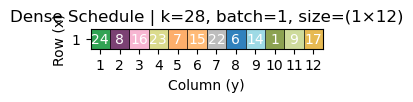

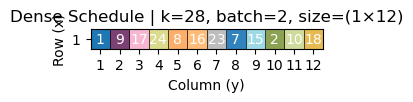

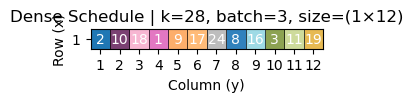

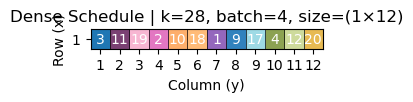

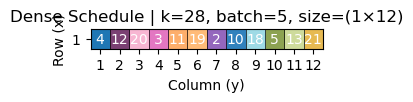

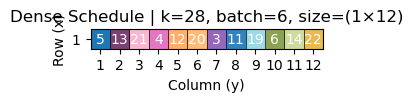

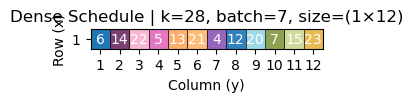

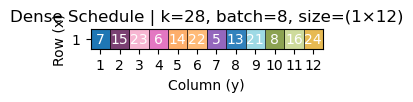

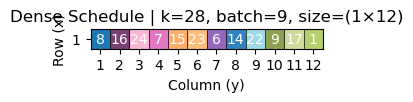

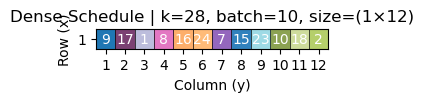

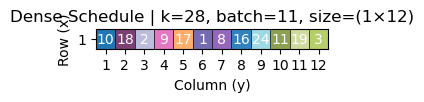

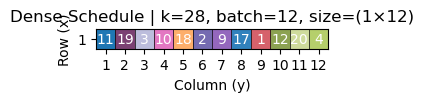

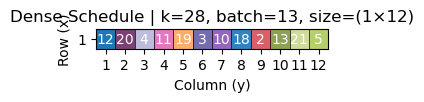

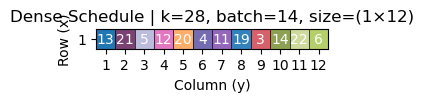

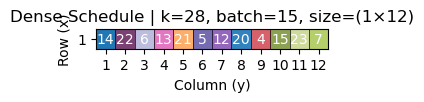

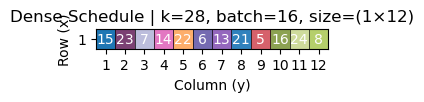

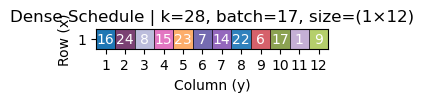

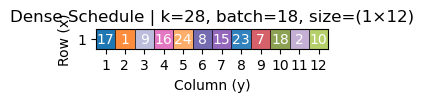

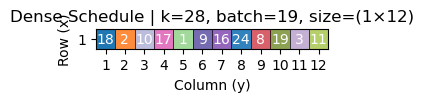

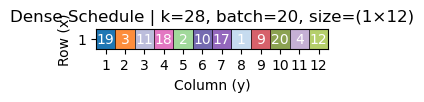

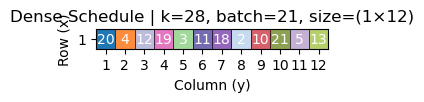

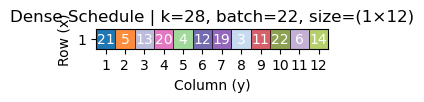

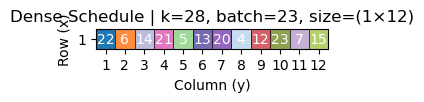

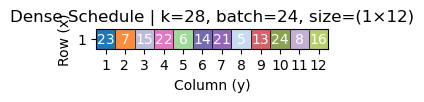

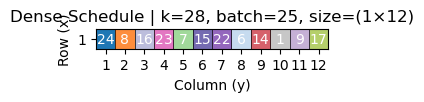

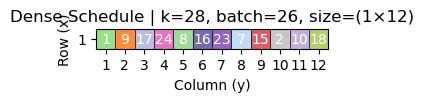

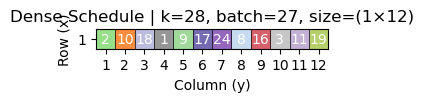

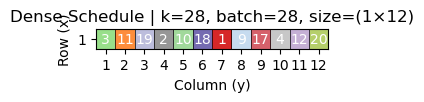

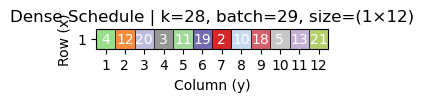

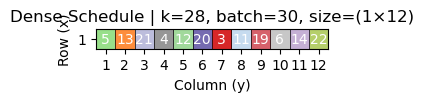

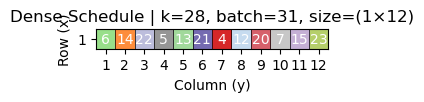

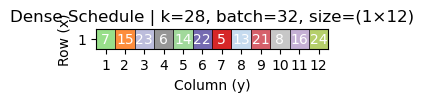

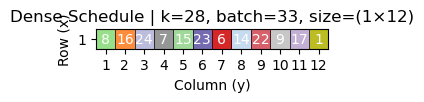

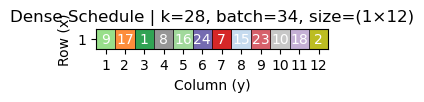

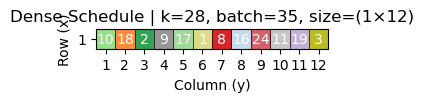

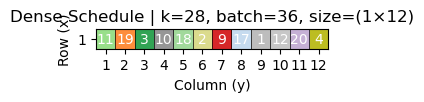

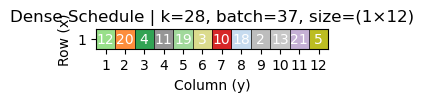

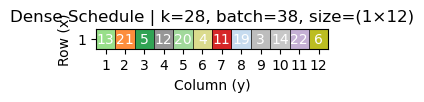

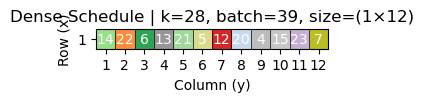

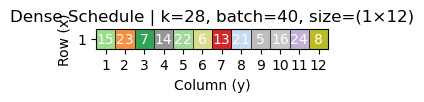

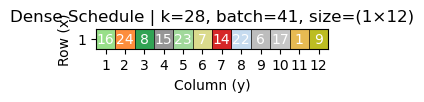

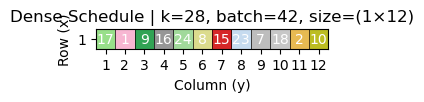

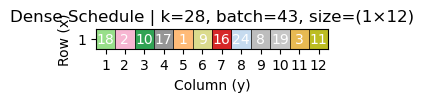

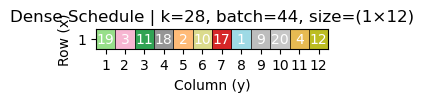

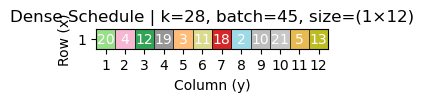

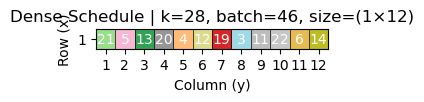

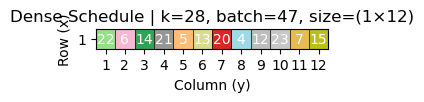

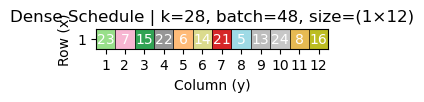

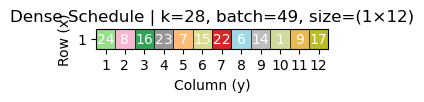

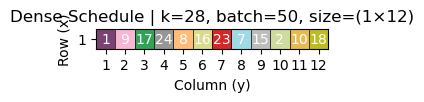

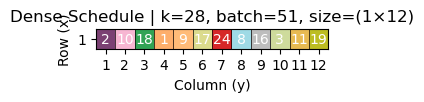

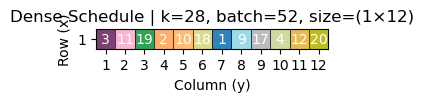

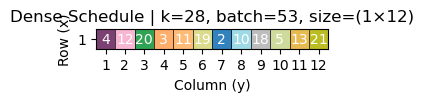

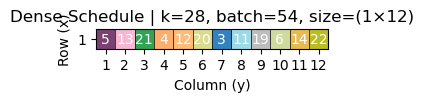

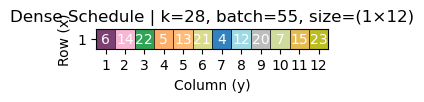

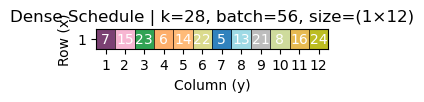

In [79]:
k, m, n,  b, N1 = 28,1,12, 4, 14

visualize_dense_schedule(m, n, k, b, N1)

k: 28
R: 48


/var/folders/dx/6lqc8b9n075260nhrpx61w_00000gn/T/ipykernel_51435/1059926473.py:78: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


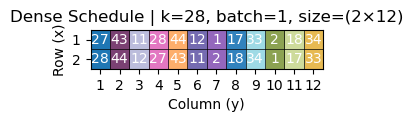

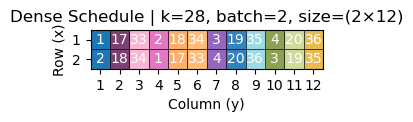

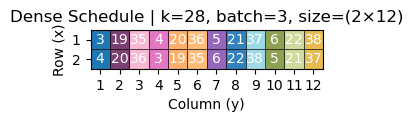

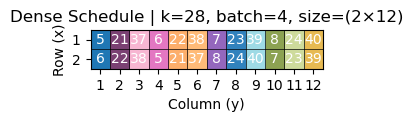

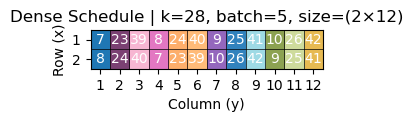

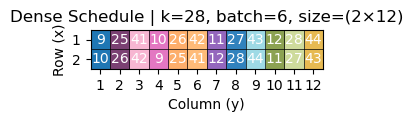

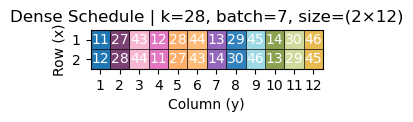

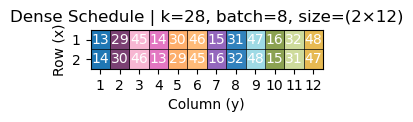

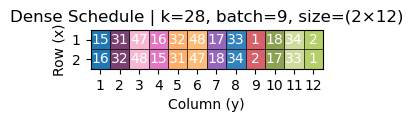

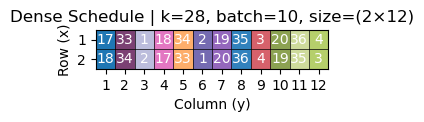

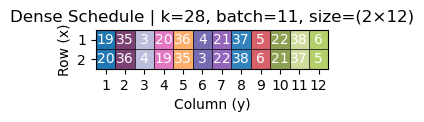

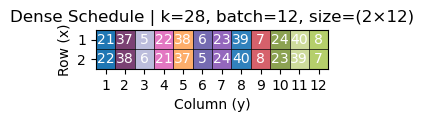

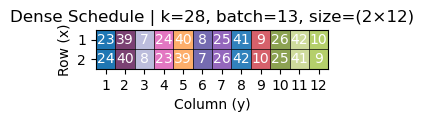

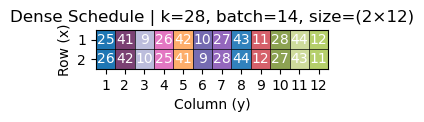

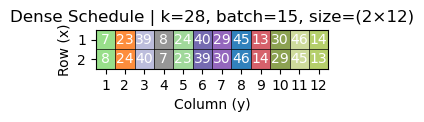

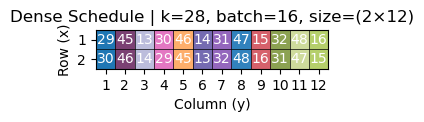

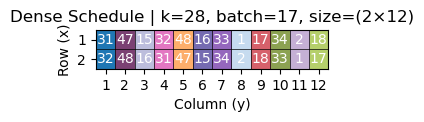

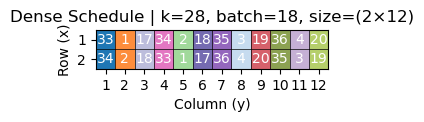

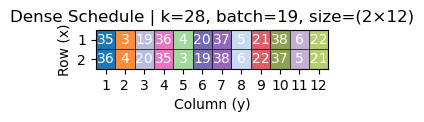

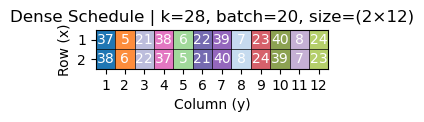

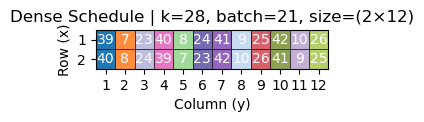

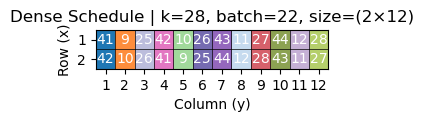

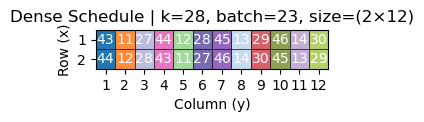

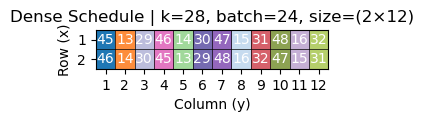

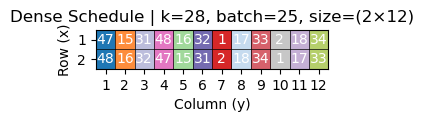

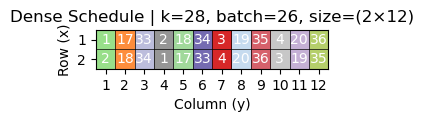

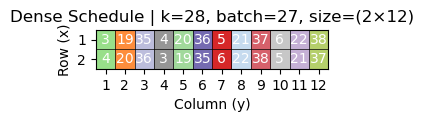

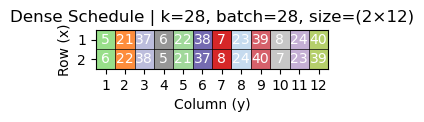

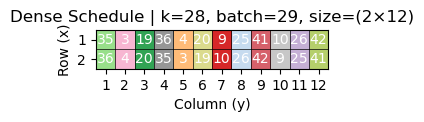

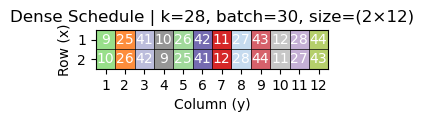

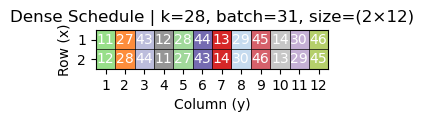

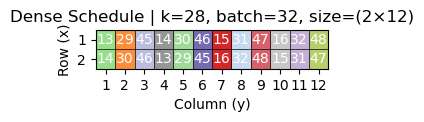

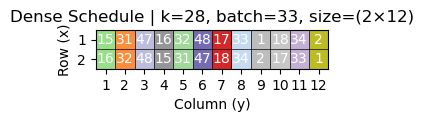

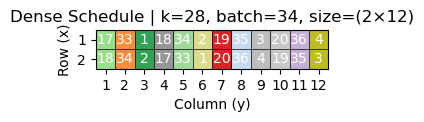

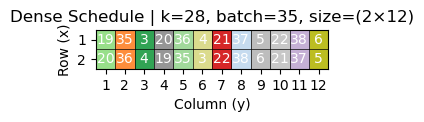

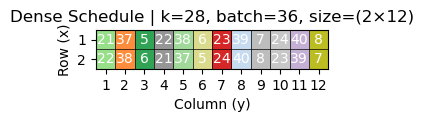

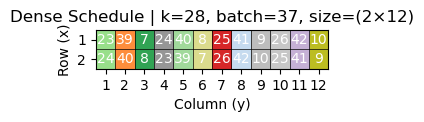

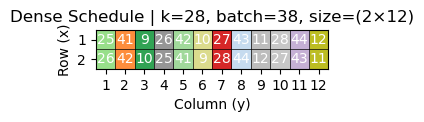

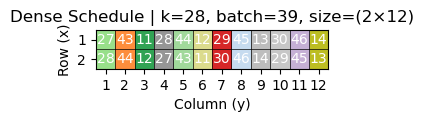

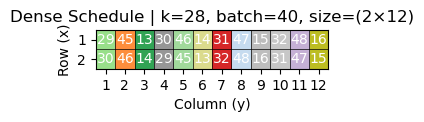

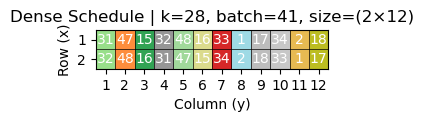

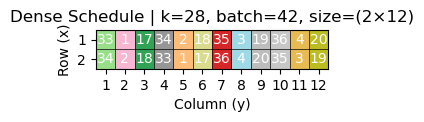

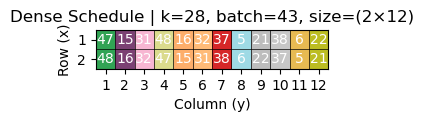

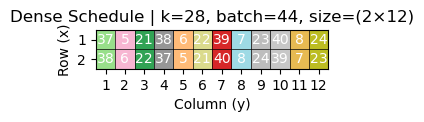

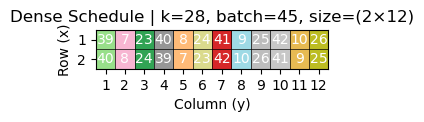

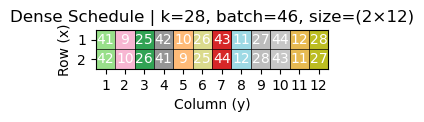

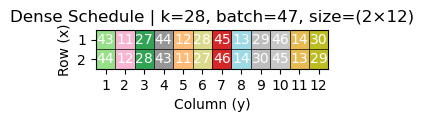

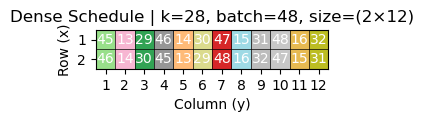

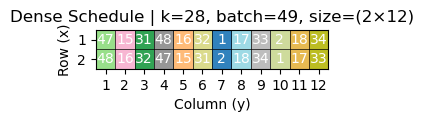

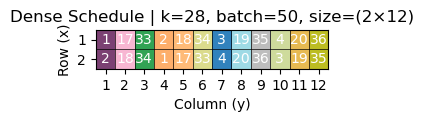

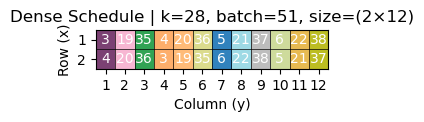

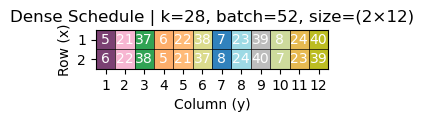

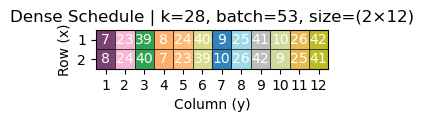

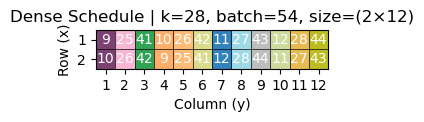

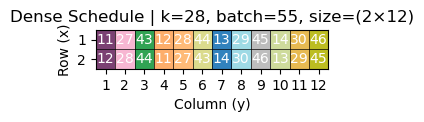

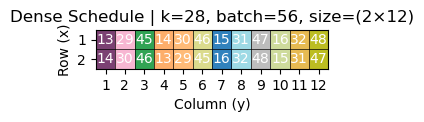

In [75]:
k, m, n,  b, N1 = 28,2,12, 4, 14

visualize_dense_schedule(m, n, k, b, N1)

k: 8
R: 64


/var/folders/dx/6lqc8b9n075260nhrpx61w_00000gn/T/ipykernel_23301/49078681.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


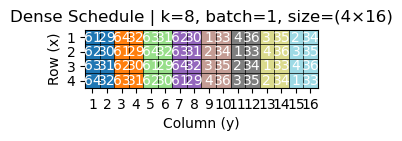

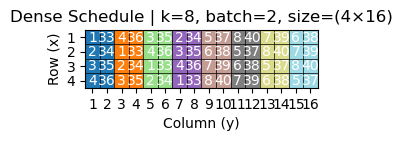

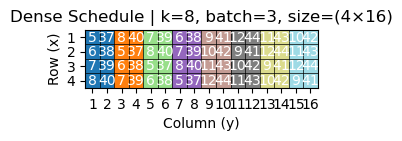

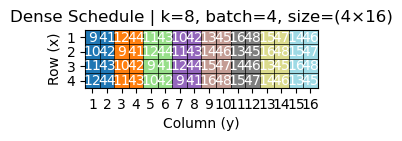

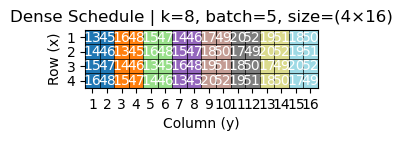

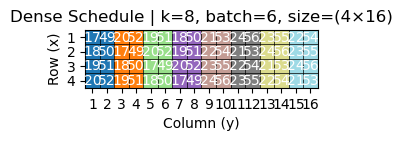

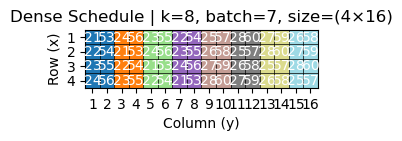

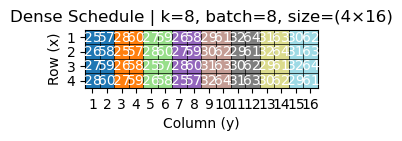

In [11]:
k, m, n,  b, N1 = 8,4,16, 1, 8

visualize_dense_schedule(m, n, k, b, N1)

k: 3
R: 24


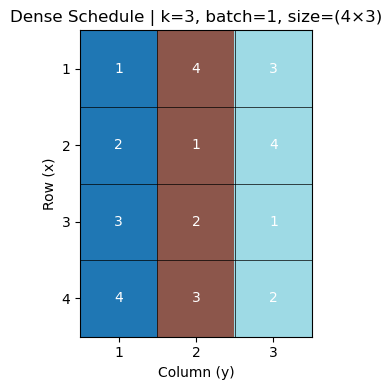

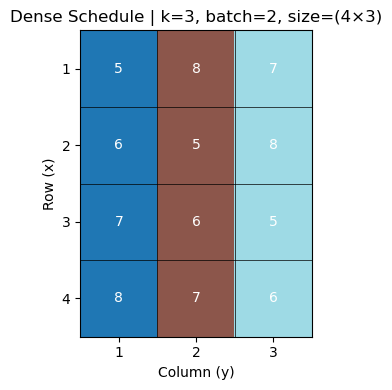

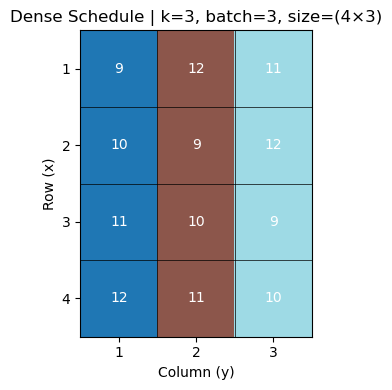

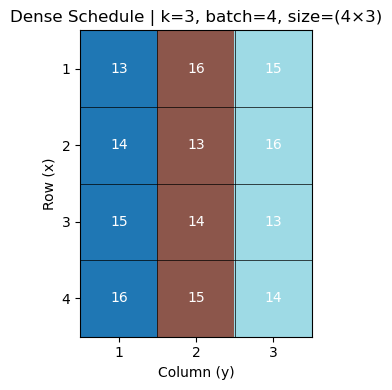

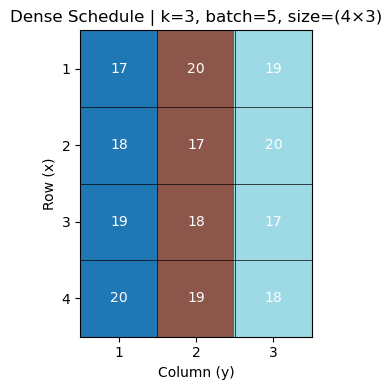

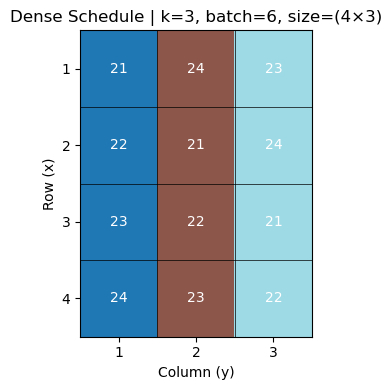

In [3]:
m, n, k, b, N1 = 4, 3, 3, 2 ,3

visualize_dense_schedule(m, n, k, b, N1)

k: 6
R: 54


/var/folders/dx/6lqc8b9n075260nhrpx61w_00000gn/T/ipykernel_32961/49078681.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


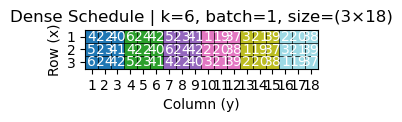

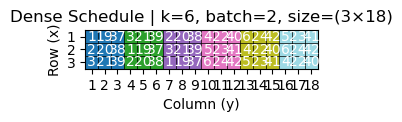

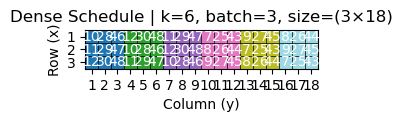

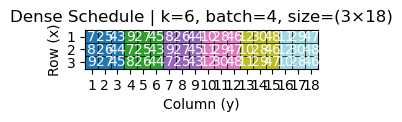

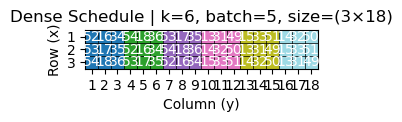

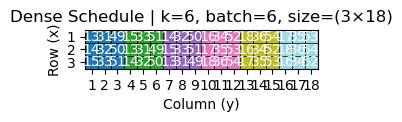

In [16]:
m, n, k, b, N1 = 3, 18, 6, 3 ,2

visualize_dense_schedule(m, n, k, b, N1)

k: 12
R: 18


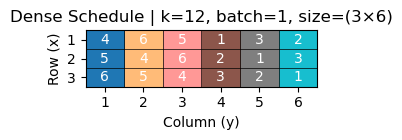

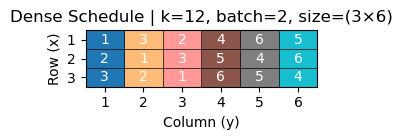

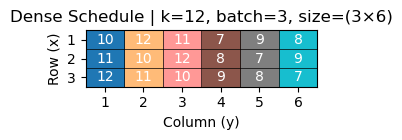

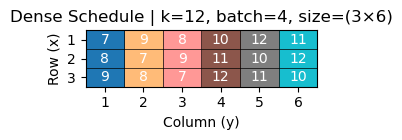

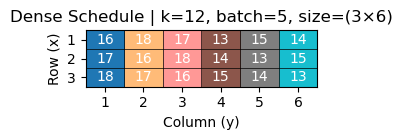

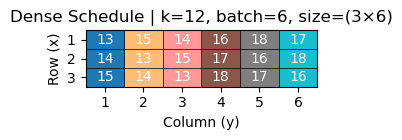

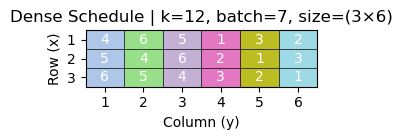

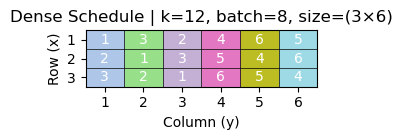

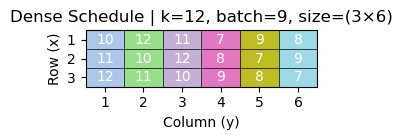

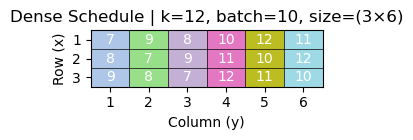

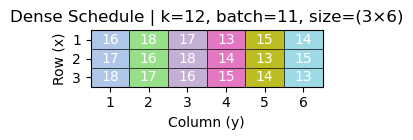

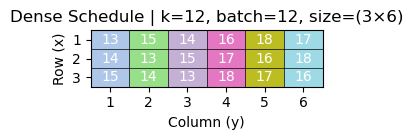

In [17]:
m, n, k, b ,N1 =3, 6, 12, 6, 2

visualize_dense_schedule(m, n, k, b, N1)

k: 6
R: 28


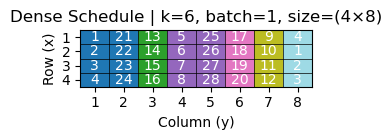

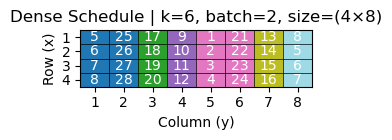

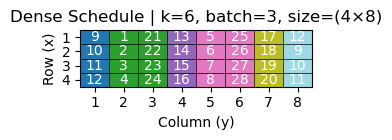

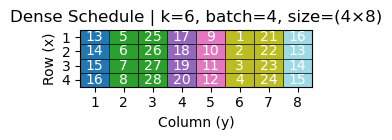

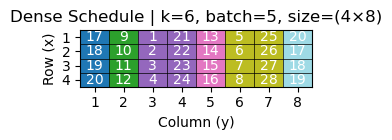

In [18]:
#内存可能不友好
m, n, k, b, N1 = 4, 8, 6, 5, 1
visualize_dense_schedule(m, n, k, b, N1)

k: 6
R: 20


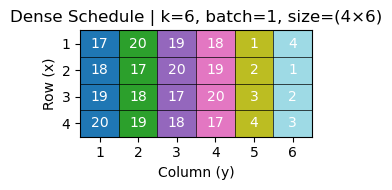

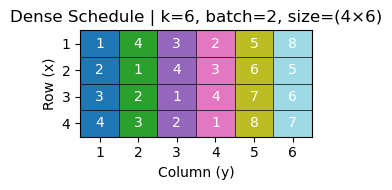

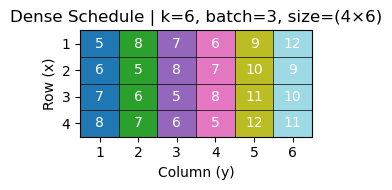

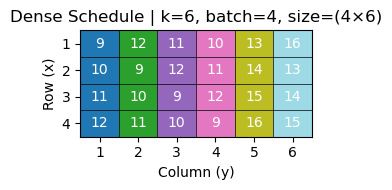

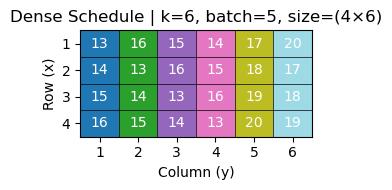

In [19]:
k, m, n, b, N1 =32, 4, 6, 1, 5
visualize_dense_schedule(m, n, k, b, N1)